# AI Study Assistant

**Author:** Tala Al-Hadawi  
**Training Program:** SDAIA Academy – Building AI Agent Systems   
**Workflow Pattern:** Supervisor–Worker  


## Project Overview

The AI Study Assistant helps students study uploaded PDF materials. It can:

- Answer questions using the uploaded documents
- Generate concise summaries
- Create multiple-choice quizzes
- Combine several workers for requests such as a complete study pack
- Retrieve relevant evidence through RAG
- Remember conversation context and user preferences
- Pause for user approval before quiz generation
- Trace the complete workflow in LangSmith

## How to Run

1. Add `GROQ_API_KEY` and,  `LANGSMITH_API_KEY` to Colab Secrets.
2. Select **Runtime → Restart session and run all**.
3. Upload at least one text-based study PDF when the upload cell appears.
4. The Human-in-the-Loop demonstration pauses in one cell and resumes in the following cell.

All definitions are ordered before use, so no manual re-running of earlier cells is required.

# Phase 1 – Environment Setup

This phase installs the required libraries, loads API keys from Colab Secrets, enables LangSmith tracing, and initialises the language model.

Required Colab Secrets:

- `GROQ_API_KEY`
- `LANGSMITH_API_KEY` (optional, but required for tracing evidence)

In [28]:
%pip install -q langgraph langchain langchain-core langchain-community langchain-groq langchain-huggingface langsmith faiss-cpu sentence-transformers pymupdf pypdf

In [29]:
import json
import os
import uuid
from pathlib import Path
from typing import Any, Literal

from google.colab import files, userdata
from pydantic import BaseModel, Field

from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyMuPDFLoader, PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.func import entrypoint, task
from langgraph.store.base import BaseStore
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command, RetryPolicy, interrupt

In [30]:
# Load secrets without exposing them in the notebook.
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

try:
    LANGSMITH_API_KEY = userdata.get("LANGSMITH_API_KEY")
except Exception:
    LANGSMITH_API_KEY = None

if not GROQ_API_KEY:
    raise ValueError("Add GROQ_API_KEY to Colab Secrets before running the notebook.")

os.environ["GROQ_API_KEY"] = GROQ_API_KEY

if LANGSMITH_API_KEY:
    os.environ["LANGSMITH_API_KEY"] = LANGSMITH_API_KEY
    os.environ["LANGSMITH_TRACING"] = "true"
    os.environ["LANGSMITH_PROJECT"] = "ai-study-assistant"
    print("LangSmith tracing enabled.")
else:
    os.environ["LANGSMITH_TRACING"] = "false"
    print("LANGSMITH_API_KEY was not found. The workflow will run without tracing.")

LangSmith tracing enabled.


In [31]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_retries=2,
)

connection_test = llm.invoke("Reply with exactly: LLM connection successful")
print(connection_test.content)


LLM connection successful


## Phase 1 Rubric Coverage

- Secure API-key handling through Colab Secrets
- Language-model initialisation
- LangSmith tracing configuration
- Reproducible dependency setup

# Phase 2 – Document Ingestion and RAG

The RAG pipeline performs the following steps:

1. Upload one or more PDF files.
2. Extract text with `PyMuPDFLoader`, with `PyPDFLoader` as a fallback.
3. Split the pages into overlapping chunks.
4. Generate Hugging Face embeddings.
5. Store the chunks in FAISS.
6. Retrieve semantically relevant evidence for each worker.

In [32]:
# Upload one or more study PDFs.
uploaded_files = files.upload()
pdf_paths = [name for name in uploaded_files if name.lower().endswith(".pdf")]

if not pdf_paths:
    raise ValueError("Please upload at least one PDF file.")

print("Uploaded PDFs:", pdf_paths)

Saving 6. Constraint Satisfaction Problems.pdf to 6. Constraint Satisfaction Problems (1).pdf
Uploaded PDFs: ['6. Constraint Satisfaction Problems (1).pdf']


In [33]:
documents = []

for pdf_path in pdf_paths:
    try:
        loaded_pages = PyMuPDFLoader(pdf_path).load()
    except Exception as pymupdf_error:
        print(f"PyMuPDFLoader failed for {pdf_path}: {pymupdf_error}")
        print("Trying PyPDFLoader instead...")
        loaded_pages = PyPDFLoader(pdf_path).load()

    for page in loaded_pages:
        page.metadata["source"] = Path(pdf_path).name

    documents.extend(loaded_pages)

if not documents:
    raise ValueError("No pages could be extracted from the uploaded PDFs.")

print(f"Loaded {len(documents)} pages from {len(pdf_paths)} PDF file(s).")

Loaded 58 pages from 1 PDF file(s).


In [34]:
# Inspect a small sample before indexing.
for index, document in enumerate(documents[:5], start=1):
    preview = document.page_content.strip().replace("\n", " ")[:160]
    print(f"Page sample {index}: {len(document.page_content)} characters | {preview!r}")

Page sample 1: 46 characters | 'Chapter 6 Constraint Satisfaction Problems i s'
Page sample 2: 573 characters | 'Constraint Satisfaction Problems • Standard search problem: • A state is a “black box” – any data structure that supports successor function,  heuristic functio'
Page sample 3: 23 characters | 'Example: map-coloring 3'
Page sample 4: 233 characters | 'Example: map-coloring 1. Variables: {WA, NT, Q, NSW, V, SA, T} 2. Domains: Di = {red, green, blue} 3. Constraints: adjacent regions must have different colors: '
Page sample 5: 265 characters | 'Example: map-coloring Solutions are complete and consistent assignments. • Complete assignment: all variables are assigned. • Consistent assignment: no constrai'


In [35]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)

all_chunks = text_splitter.split_documents(documents)
valid_chunks = [
    chunk for chunk in all_chunks
    if len(chunk.page_content.strip()) >= 80
]

# Keep non-empty chunks if the PDF consists mainly of short presentation slides.
if not valid_chunks:
    valid_chunks = [
        chunk for chunk in all_chunks
        if chunk.page_content.strip()
    ]

if not valid_chunks:
    raise ValueError("The uploaded PDF does not contain extractable text. A scanned PDF may require OCR.")

print(f"All chunks: {len(all_chunks)}")
print(f"Indexed chunks: {len(valid_chunks)}")

All chunks: 58
Indexed chunks: 45


In [36]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

vector_store = FAISS.from_documents(valid_chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

print("FAISS vector store and retriever created successfully.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

FAISS vector store and retriever created successfully.


In [37]:

DEMO_TOPIC = "constraint satisfaction problems"

retrieval_test = retriever.invoke(DEMO_TOPIC)
for index, document in enumerate(retrieval_test, start=1):
    source = Path(document.metadata.get("source", "uploaded PDF")).name
    page = document.metadata.get("page")
    page_label = f"page {page + 1}" if isinstance(page, int) else "page unknown"
    print(f"\nResult {index} — {source}, {page_label}")
    print(document.page_content[:350])


Result 1 — 6. Constraint Satisfaction Problems (1).pdf, page 2
Constraint Satisfaction Problems
• Standard search problem:
• A state is a “black box” – any data structure that supports successor function, 
heuristic function and goal test.
• CSP:
• A state is defined by variables !! with values from domains "! (factored 
representation)
• Goal test is a set of constraints specifying allowable combinations of v

Result 2 — 6. Constraint Satisfaction Problems (1).pdf, page 8
Constraint graph
8
• A binary CSP can be represented by a constraint graph: nodes are 
variables, arcs are constraints
WA
NT
SA
Q
NSW
V
T

Result 3 — 6. Constraint Satisfaction Problems (1).pdf, page 7
Varieties of CSP
• Constraints can be:
• Unary: apply to one variable. Example: SA ≠ green.
• Binary: relate two variables. Example: SA ≠ WA.
• N-ary (or higher-order) constraints: involve 3 or more variables. Example: 
Sudoku.
• A CSP with n-ary constraints can always be transformed to a CSP with 
binary constraints


## Phase 2 Rubric Coverage

- Real uploaded documents
- Text loading and chunking
- Embedding generation
- FAISS vector database
- Semantic retrieval
- Source metadata retained for grounded answers

# Phase 3 – Agent Fundamentals

This phase defines:

- A real retrieval tool
- Pydantic structured-output schemas
- Specialised QA, Summary, and Quiz agents
- A structured orchestration plan
- A final synthesis schema

In [38]:
class SummaryOutput(BaseModel):
    summary: str = Field(description="A concise summary grounded in the retrieved material.")
    key_points: list[str] = Field(description="The most important facts from the material.")


class QAOutput(BaseModel):
    answer: str = Field(description="A direct answer grounded in the retrieved material.")


class QuizQuestion(BaseModel):
    question: str
    options: list[str] = Field(description="Exactly four answer options.", min_length=4, max_length=4)
    correct_answer: str
    explanation: str


class QuizOutput(BaseModel):
    questions: list[QuizQuestion]


class WorkerTask(BaseModel):
    worker: Literal["qa", "summary", "quiz"]
    instruction: str = Field(description="A specific instruction for the selected worker.")


class OrchestrationPlan(BaseModel):
    tasks: list[WorkerTask] = Field(
        description="One or more worker tasks required to complete the request.",
        min_length=1,
    )
    reason: str = Field(description="Why these workers were selected.")


class SynthesisOutput(BaseModel):
    final_answer: str = Field(description="A complete response combining all worker outputs.")

In [39]:
def _format_retrieved_documents(query: str) -> dict[str, Any]:
    docs = retriever.invoke(query)
    sources = []
    sections = []

    for document in docs:
        source_name = Path(document.metadata.get("source", "uploaded PDF")).name
        page = document.metadata.get("page")
        source_label = (
            f"{source_name}, page {page + 1}"
            if isinstance(page, int)
            else source_name
        )

        if source_label not in sources:
            sources.append(source_label)

        sections.append(
            f"[Source: {source_label}]\n{document.page_content.strip()}"
        )

    return {
        "query": query,
        "context": "\n\n".join(sections),
        "sources": sources,
    }


@tool
def search_study_material(query: str) -> str:
    """Retrieve relevant evidence from the uploaded study PDFs."""
    payload = _format_retrieved_documents(query)
    return json.dumps(payload, ensure_ascii=False)

In [40]:
tool_test = json.loads(
    search_study_material.invoke({"query": DEMO_TOPIC})
)

print("Retrieved sources:")
for source in tool_test["sources"]:
    print("-", source)

print("\nContext preview:")
print(tool_test["context"][:700])

Retrieved sources:
- 6. Constraint Satisfaction Problems (1).pdf, page 2
- 6. Constraint Satisfaction Problems (1).pdf, page 8
- 6. Constraint Satisfaction Problems (1).pdf, page 7
- 6. Constraint Satisfaction Problems (1).pdf, page 12

Context preview:
[Source: 6. Constraint Satisfaction Problems (1).pdf, page 2]
Constraint Satisfaction Problems
• Standard search problem:
• A state is a “black box” – any data structure that supports successor function, 
heuristic function and goal test.
• CSP:
• A state is defined by variables !! with values from domains "! (factored 
representation)
• Goal test is a set of constraints specifying allowable combinations of values for  
variables.
• The CSP formalism allows for more powerful algorithms than standard 
search algorithms: take advantage of the structure of states and use 
general-purpose rather than problem-specific heuristics
2
&

[Source: 6. Constraint Satisfaction Problems (1).pdf, page 8]
C


In [41]:

summary_llm = llm.with_structured_output(SummaryOutput, method="json_mode")
qa_llm = llm.with_structured_output(QAOutput, method="json_mode")
quiz_llm = llm.with_structured_output(QuizOutput, method="json_mode")
planner_llm = llm.with_structured_output(OrchestrationPlan, method="json_mode")


def schema_instructions(schema: type[BaseModel]) -> str:
    """Return explicit JSON-only instructions for Groq JSON mode."""
    return (
        "Return ONLY one valid JSON object. Do not use Markdown or code fences. "
        "The JSON must match this schema exactly:\n"
        + json.dumps(schema.model_json_schema(), ensure_ascii=False, indent=2)
    )


print("Reliable JSON-mode structured models initialised successfully.")


Reliable JSON-mode structured models initialised successfully.


In [42]:
def _history_to_text(history: list[dict[str, str]]) -> str:
    if not history:
        return "No previous conversation."

    return "\n".join(
        f"{message['role'].title()}: {message['content']}"
        for message in history[-8:]
    )


def run_summary_agent(
    instruction: str,
    history: list[dict[str, str]],
    preferences: dict[str, Any],
) -> dict[str, Any]:
    retrieval = json.loads(
        search_study_material.invoke({"query": instruction})
    )

    result = summary_llm.invoke(
        f"""
You are the Summary Worker in an AI Study Assistant.

Worker instruction:
{instruction}

Preferred explanation style:
{preferences['explanation_style']}

Conversation history:
{_history_to_text(history)}

Retrieved study material:
{retrieval['context']}

Use only the retrieved study material. If the evidence is insufficient, state that clearly.

{schema_instructions(SummaryOutput)}
"""
    )

    return {
        "worker": "summary",
        "instruction": instruction,
        "output": result.model_dump(),
        "sources": retrieval["sources"],
    }


def run_qa_agent(
    instruction: str,
    history: list[dict[str, str]],
    preferences: dict[str, Any],
) -> dict[str, Any]:
    retrieval = json.loads(
        search_study_material.invoke({"query": instruction})
    )

    result = qa_llm.invoke(
        f"""
You are the Question Answering Worker in an AI Study Assistant.

Worker instruction:
{instruction}

Preferred explanation style:
{preferences['explanation_style']}

Conversation history:
{_history_to_text(history)}

Retrieved study material:
{retrieval['context']}

Answer using only the retrieved material. If the answer is not supported, say that the uploaded material does not provide enough information.

{schema_instructions(QAOutput)}
"""
    )

    return {
        "worker": "qa",
        "instruction": instruction,
        "output": result.model_dump(),
        "sources": retrieval["sources"],
    }


def run_quiz_agent(
    instruction: str,
    history: list[dict[str, str]],
    preferences: dict[str, Any],
) -> dict[str, Any]:
    retrieval = json.loads(
        search_study_material.invoke({"query": instruction})
    )

    result = quiz_llm.invoke(
        f"""
You are the Quiz Worker in an AI Study Assistant.

Worker instruction:
{instruction}

Default quiz settings:
- Difficulty: {preferences['quiz_difficulty']}
- Question count: {preferences['quiz_question_count']}

Conversation history:
{_history_to_text(history)}

Retrieved study material:
{retrieval['context']}

Use only the retrieved material. Each question must have exactly four options, one correct answer, and a short explanation. Follow an explicit question count in the worker instruction; otherwise use the default count.

{schema_instructions(QuizOutput)}
"""
    )

    return {
        "worker": "quiz",
        "instruction": instruction,
        "output": result.model_dump(),
        "sources": retrieval["sources"],
    }


## Phase 3 Rubric Coverage

- Real LangChain retrieval tool
- Tool accepts a query argument and performs semantic retrieval
- Pydantic structured outputs
- Three specialised worker agents
- Grounded outputs with source metadata

# Phase 4 – Orchestrator–Worker Workflow and Error Handling

The orchestrator does more than route to one agent. It creates a structured plan containing one or multiple worker tasks. For a combined request, several workers can execute and a synthesiser combines their results.

The workflow is implemented with the real LangGraph **Functional API** using `@task` and `@entrypoint`.

Two complementary error-handling strategies are implemented:

1. **Automatic retries:** LLM-dependent tasks use `RetryPolicy` with exponential backoff for transient failures such as timeouts, rate limits, and server errors.
2. **Graceful fallbacks:** `try/except` paths return a safe plan, a worker-level fallback result, or a deterministic synthesis when an error is non-retryable or retries are exhausted.


In [43]:
DEFAULT_PREFERENCES = {
    "explanation_style": "simple",
    "quiz_difficulty": "medium",
    "quiz_question_count": 5,
}

checkpointer = InMemorySaver()
long_term_store = InMemoryStore()


def _preference_namespace(user_id: str) -> tuple[str, str]:
    return ("users", user_id)


def set_user_preferences(user_id: str, **updates: Any) -> dict[str, Any]:
    """Save user preferences in the LangGraph long-term memory store."""
    namespace = _preference_namespace(user_id)
    stored_item = long_term_store.get(namespace, "preferences")
    preferences = (
        dict(stored_item.value)
        if stored_item is not None
        else dict(DEFAULT_PREFERENCES)
    )

    allowed_keys = set(DEFAULT_PREFERENCES)
    preferences.update({key: value for key, value in updates.items() if key in allowed_keys})
    long_term_store.put(namespace, "preferences", preferences)
    return preferences


def read_user_preferences(user_id: str) -> dict[str, Any]:
    namespace = _preference_namespace(user_id)
    stored_item = long_term_store.get(namespace, "preferences")
    return (
        dict(stored_item.value)
        if stored_item is not None
        else dict(DEFAULT_PREFERENCES)
    )


def should_retry_transient_error(error: Exception) -> bool:
    """Retry only failures that are likely to succeed on a later attempt."""
    status_code = getattr(error, "status_code", None)

    if status_code in {408, 409, 425, 429}:
        return True

    if isinstance(status_code, int) and status_code >= 500:
        return True

    return isinstance(error, (TimeoutError, ConnectionError))


LLM_RETRY_POLICY = RetryPolicy(
    initial_interval=1.0,
    backoff_factor=2.0,
    max_interval=8.0,
    max_attempts=3,
    jitter=True,
    retry_on=should_retry_transient_error,
)


def _error_name(error: Exception) -> str:
    return type(error).__name__


def build_fallback_plan(user_request: str, error: Exception) -> dict[str, Any]:
    """Safe emergency plan used only when structured orchestration fails."""
    return {
        "tasks": [
            {
                "worker": "qa",
                "instruction": user_request,
            }
        ],
        "reason": (
            "Fallback plan used because the orchestrator could not produce a "
            "valid structured plan. The QA worker will provide the safest "
            "grounded response available."
        ),
        "fallback_used": True,
        "error_type": _error_name(error),
    }


def build_worker_fallback(
    worker: str,
    instruction: str,
    error: Exception,
) -> dict[str, Any]:
    """Return a serialisable worker result instead of crashing the workflow."""
    return {
        "worker": worker,
        "instruction": instruction,
        "output": {
            "status": "fallback",
            "message": (
                f"The {worker} worker could not complete this task. "
                "The workflow continued safely; please retry this part later."
            ),
        },
        "sources": [],
        "fallback_used": True,
        "error_type": _error_name(error),
    }


def _worker_output_to_text(worker_output: dict[str, Any]) -> str:
    """Convert a structured worker output into readable text without an LLM."""
    worker = worker_output.get("worker", "worker")
    output = worker_output.get("output", {})

    if worker == "qa" and output.get("answer"):
        return f"Answer:\n{output['answer']}"

    if worker == "summary":
        summary = output.get("summary", "")
        key_points = output.get("key_points", [])
        points_text = "\n".join(f"- {point}" for point in key_points)
        return f"Summary:\n{summary}\n\nKey points:\n{points_text}".strip()

    if worker == "quiz" and output.get("questions"):
        quiz_lines = ["Quiz:"]
        for index, question in enumerate(output["questions"], start=1):
            quiz_lines.append(f"\n{index}. {question.get('question', '')}")
            for option in question.get("options", []):
                quiz_lines.append(f"- {option}")
            quiz_lines.append(f"Correct answer: {question.get('correct_answer', '')}")
            quiz_lines.append(f"Explanation: {question.get('explanation', '')}")
        return "\n".join(quiz_lines)

    if output.get("status") == "cancelled by user":
        return "Quiz generation was cancelled by the user."

    if output.get("message"):
        return output["message"]

    return json.dumps(output, ensure_ascii=False, indent=2)


def build_synthesis_fallback(
    worker_outputs: list[dict[str, Any]],
    error: Exception,
) -> dict[str, Any]:
    """Deterministically combine outputs when the synthesiser LLM fails."""
    sources = []
    for output in worker_outputs:
        for source in output.get("sources", []):
            if source not in sources:
                sources.append(source)

    readable_sections = [
        _worker_output_to_text(output)
        for output in worker_outputs
    ]

    return {
        "final_answer": "\n\n".join(section for section in readable_sections if section),
        "completed_workers": [output.get("worker", "unknown") for output in worker_outputs],
        "sources": sources,
        "fallback_used": True,
        "error_type": _error_name(error),
    }


print("Error handling configured: RetryPolicy + graceful fallback paths.")


Error handling configured: RetryPolicy + graceful fallback paths.


In [44]:
@task(retry_policy=LLM_RETRY_POLICY)
def create_orchestration_plan(
    user_request: str,
    history: list[dict[str, str]],
) -> dict[str, Any]:
    try:
        plan = planner_llm.invoke(
            f"""
You are the Orchestrator of an AI Study Assistant.

Available workers:
- qa: answers or explains a specific question using the uploaded material
- summary: creates a concise summary or key points
- quiz: generates practice questions or multiple-choice quizzes

Create one or more worker tasks that fully satisfy the user's request.

Rules:
- Select only the workers that are needed.
- Use multiple workers for combined requests, such as a study pack containing a summary and quiz.
- Write a self-contained instruction for each worker.
- Resolve follow-up references such as 'it' using the conversation history.
- Do not use keyword matching; reason about the user's intent.

Conversation history:
{_history_to_text(history)}

User request:
{user_request}

{schema_instructions(OrchestrationPlan)}
"""
        )
        result = plan.model_dump()
        result["fallback_used"] = False
        return result

    except Exception as error:
        # Transient failures are re-raised so RetryPolicy can retry them.
        if should_retry_transient_error(error):
            raise

        # Non-retryable structured-output errors use a safe plan.
        return build_fallback_plan(user_request, error)


@task(retry_policy=LLM_RETRY_POLICY)
def summary_worker_task(payload: dict[str, Any]) -> dict[str, Any]:
    try:
        result = run_summary_agent(**payload)
        result["fallback_used"] = False
        return result
    except Exception as error:
        if should_retry_transient_error(error):
            raise
        return build_worker_fallback("summary", payload["instruction"], error)


@task(retry_policy=LLM_RETRY_POLICY)
def qa_worker_task(payload: dict[str, Any]) -> dict[str, Any]:
    try:
        result = run_qa_agent(**payload)
        result["fallback_used"] = False
        return result
    except Exception as error:
        if should_retry_transient_error(error):
            raise
        return build_worker_fallback("qa", payload["instruction"], error)


@task(retry_policy=LLM_RETRY_POLICY)
def quiz_worker_task(payload: dict[str, Any]) -> dict[str, Any]:
    try:
        result = run_quiz_agent(**payload)
        result["fallback_used"] = False
        return result
    except Exception as error:
        if should_retry_transient_error(error):
            raise
        return build_worker_fallback("quiz", payload["instruction"], error)


@task
def request_quiz_approval(plan: dict[str, Any]) -> bool:
    # No retry policy is needed here because interrupt is a deterministic,
    # local Human-in-the-Loop operation rather than an external API call.
    decision = interrupt(
        {
            "action": "quiz_generation",
            "question": "Approve quiz generation?",
            "planned_tasks": plan["tasks"],
            "resume_example": {"approved": True},
        }
    )

    if isinstance(decision, dict):
        return bool(decision.get("approved", False))

    if isinstance(decision, bool):
        return decision

    return str(decision).strip().lower() in {"yes", "y", "true", "approve", "approved"}


@task(retry_policy=LLM_RETRY_POLICY)
def synthesise_worker_outputs(
    user_request: str,
    worker_outputs: list[dict[str, Any]],
) -> dict[str, Any]:
    try:
        response = llm.invoke(
            f"""
You are the Synthesiser of an AI Study Assistant.

Original user request:
{user_request}

Worker outputs:
{json.dumps(worker_outputs, ensure_ascii=False, indent=2)}

Combine the worker outputs into one clear final response.
Preserve quiz questions, all answer choices, correct answers, and explanations when present.
Do not add unsupported facts.
Return only the final response for the student.
"""
        )

        sources = []
        for output in worker_outputs:
            for source in output.get("sources", []):
                if source not in sources:
                    sources.append(source)

        return {
            "final_answer": response.content.strip(),
            "completed_workers": [output["worker"] for output in worker_outputs],
            "sources": sources,
            "fallback_used": False,
        }

    except Exception as error:
        if should_retry_transient_error(error):
            raise
        return build_synthesis_fallback(worker_outputs, error)


In [45]:
@entrypoint(
    checkpointer=checkpointer,
    store=long_term_store
)
def study_assistant_workflow(
    inputs: dict[str, Any],
    *,
    previous: dict[str, Any] | None = None,
    store: BaseStore,
):
    """
    Main LangGraph Functional API workflow.
    """

    user_request = str(
        inputs["request"]
    ).strip()

    user_id = str(
        inputs.get("user_id", "default-user")
    )

    if not user_request:
        raise ValueError(
            "The request cannot be empty."
        )

    previous_state = previous or {
        "messages": []
    }

    history = list(
        previous_state.get("messages", [])
    )

    error_events: list[dict[str, str]] = []



    namespace = _preference_namespace(user_id)

    stored_item = store.get(
        namespace,
        "preferences"
    )

    preferences = (
        dict(stored_item.value)
        if stored_item is not None
        else dict(DEFAULT_PREFERENCES)
    )

    preference_updates = (
        inputs.get("preferences") or {}
    )

    if preference_updates:
        allowed_keys = set(
            DEFAULT_PREFERENCES
        )

        preferences.update(
            {
                key: value
                for key, value
                in preference_updates.items()
                if key in allowed_keys
            }
        )

        store.put(
            namespace,
            "preferences",
            preferences
        )


    try:
        plan = create_orchestration_plan(
            user_request,
            history
        ).result()

    except Exception as error:
        plan = build_fallback_plan(
            user_request,
            error
        )

        error_events.append(
            {
                "stage": "orchestrator",
                "error_type": _error_name(error)
            }
        )

    if plan.get("fallback_used"):
        error_events.append(
            {
                "stage": "orchestrator_fallback",
                "error_type": plan.get(
                    "error_type",
                    "UnknownError"
                ),
            }
        )

    # Show which workers were selected
    print(
        "Planned workers:",
        [
            planned_task["worker"]
            for planned_task in plan["tasks"]
        ]
    )



    scheduled_workers = []
    quiz_payloads = []

    for planned_task in plan["tasks"]:

        payload = {
            "instruction": (
                planned_task["instruction"]
            ),
            "history": history,
            "preferences": preferences,
        }

        worker_name = planned_task["worker"]

        if worker_name == "summary":
            scheduled_workers.append(
                (
                    worker_name,
                    payload,
                    summary_worker_task(payload)
                )
            )

        elif worker_name == "qa":
            scheduled_workers.append(
                (
                    worker_name,
                    payload,
                    qa_worker_task(payload)
                )
            )

        elif worker_name == "quiz":
            # Quiz is delayed until human approval.
            quiz_payloads.append(payload)

        else:
            error = ValueError(
                f"Unsupported worker: {worker_name}"
            )

            scheduled_workers.append(
                (
                    worker_name,
                    payload,
                    None
                )
            )

            error_events.append(
                {
                    "stage": worker_name,
                    "error_type": _error_name(error)
                }
            )


    worker_outputs = []

    for worker_name, payload, future in scheduled_workers:

        if future is None:
            worker_outputs.append(
                build_worker_fallback(
                    worker_name,
                    payload["instruction"],
                    ValueError(
                        f"Unsupported worker: {worker_name}"
                    ),
                )
            )
            continue

        try:
            worker_result = future.result()

        except Exception as error:
            worker_result = build_worker_fallback(
                worker_name,
                payload["instruction"],
                error,
            )

            error_events.append(
                {
                    "stage": worker_name,
                    "error_type": _error_name(error)
                }
            )

        if worker_result.get(
            "fallback_used"
        ):
            error_events.append(
                {
                    "stage": (
                        f"{worker_name}_fallback"
                    ),
                    "error_type": (
                        worker_result.get(
                            "error_type",
                            "UnknownError"
                        )
                    ),
                }
            )

        worker_outputs.append(
            worker_result
        )



    if quiz_payloads:

        print(
            "Human-in-the-Loop reached: "
            "waiting for quiz approval."
        )

        approved = request_quiz_approval(
            plan
        ).result()

        if approved:

            print(
                "Quiz approved. "
                "Running Quiz Worker."
            )

            quiz_futures = [
                quiz_worker_task(payload)
                for payload in quiz_payloads
            ]

            for payload, future in zip(
                quiz_payloads,
                quiz_futures
            ):

                try:
                    quiz_result = future.result()

                except Exception as error:
                    quiz_result = (
                        build_worker_fallback(
                            "quiz",
                            payload["instruction"],
                            error,
                        )
                    )

                    error_events.append(
                        {
                            "stage": "quiz",
                            "error_type": (
                                _error_name(error)
                            )
                        }
                    )

                if quiz_result.get(
                    "fallback_used"
                ):
                    error_events.append(
                        {
                            "stage": "quiz_fallback",
                            "error_type": (
                                quiz_result.get(
                                    "error_type",
                                    "UnknownError"
                                )
                            ),
                        }
                    )

                worker_outputs.append(
                    quiz_result
                )

        else:

            print(
                "Quiz rejected by the user."
            )

            worker_outputs.append(
                {
                    "worker": "quiz",
                    "instruction": (
                        "Quiz generation"
                    ),
                    "output": {
                        "status": (
                            "cancelled by user"
                        )
                    },
                    "sources": [],
                    "fallback_used": False,
                }
            )


    try:
        final_result = (
            synthesise_worker_outputs(
                user_request,
                worker_outputs,
            ).result()
        )

    except Exception as error:
        final_result = (
            build_synthesis_fallback(
                worker_outputs,
                error
            )
        )

        error_events.append(
            {
                "stage": "synthesiser",
                "error_type": _error_name(error)
            }
        )

    if final_result.get(
        "fallback_used"
    ):
        error_events.append(
            {
                "stage": "synthesiser_fallback",
                "error_type": final_result.get(
                    "error_type",
                    "UnknownError"
                ),
            }
        )



    final_result["plan"] = plan

    final_result["preferences"] = (
        preferences
    )

    final_result["error_handling"] = {
        "retry_policy": {
            "max_attempts": (
                LLM_RETRY_POLICY.max_attempts
            ),
            "initial_interval": (
                LLM_RETRY_POLICY.initial_interval
            ),
            "backoff_factor": (
                LLM_RETRY_POLICY.backoff_factor
            ),
        },
        "fallback_used": bool(
            error_events
        ),
        "events": error_events,
    }



    updated_history = history + [
        {
            "role": "user",
            "content": user_request
        },
        {
            "role": "assistant",
            "content": (
                final_result["final_answer"]
            )
        },
    ]

    saved_state = {
        "messages": updated_history[-12:]
    }

    return entrypoint.final(
        value=final_result,
        save=saved_state,
    )

In [46]:
def display_workflow_result(result: dict[str, Any]) -> None:
    print(result["final_answer"])
    print("\nCompleted workers:", ", ".join(result["completed_workers"]))

    if result.get("sources"):
        print("\nSources:")
        for source in result["sources"]:
            print("-", source)

    print("\nOrchestrator reason:", result["plan"]["reason"])

    error_handling = result.get("error_handling", {})
    if error_handling.get("fallback_used"):
        print("\nFallback path used:")
        for event in error_handling.get("events", []):
            print(f"- {event['stage']}: {event['error_type']}")
    else:
        print("\nError handling: no fallback was required.")


## Phase 4 Rubric Coverage

- True Orchestrator–Worker planning
- One or multiple worker tasks per request
- Parallel-ready LangGraph tasks
- Dedicated synthesiser
- Functional API implemented with `@task` and `@entrypoint`
- LLM-based decisions rather than keyword matching
- **Retry strategy:** `RetryPolicy` is attached to the orchestrator, all LLM workers, and the synthesiser
- **Fallback strategy:** `try/except` paths provide safe planning, worker, and synthesis fallbacks
- Transient errors use exponential backoff; non-retryable errors fail gracefully without terminating the complete workflow


## Error-Handling Evidence

The workflow implements both error strategies required by the rubric:

| Strategy | Implementation | Behaviour |
|---|---|---|
| Automatic retry | `RetryPolicy(max_attempts=3, backoff_factor=2.0)` on LLM-dependent `@task` functions | Retries timeouts, rate limits, and server-side failures |
| Graceful fallback | `try/except` in tasks and defensive handling in the entrypoint | Uses a safe QA plan, worker error result, or deterministic synthesis instead of crashing |

The Human-in-the-Loop approval task does not use retries because it performs no external API call.


# Phase 5 – Memory

- **Short-term memory:** `InMemorySaver` checkpoints conversation state by `thread_id`. The `previous` parameter supplies earlier messages to follow-up requests.
- **Long-term memory:** `InMemoryStore` stores preferences by `user_id`, allowing them to be reused across different conversation threads during the application session.

For production, these in-memory components should be replaced with database-backed checkpointers and stores.

In [47]:
USER_ID = "tala-demo"

saved_preferences = set_user_preferences(
    USER_ID,
    explanation_style="simple",
    quiz_difficulty="medium",
    quiz_question_count=5,
)

print("Saved long-term preferences:", saved_preferences)

Saved long-term preferences: {'explanation_style': 'simple', 'quiz_difficulty': 'medium', 'quiz_question_count': 5}


In [48]:
# First turn in a conversation thread.
memory_config = {"configurable": {"thread_id": "memory-demo-thread"}}

first_result = study_assistant_workflow.invoke(
    {
        "request": f"What is {DEMO_TOPIC}?",
        "user_id": USER_ID,
    },
    config=memory_config,
)

display_workflow_result(first_result)

Planned workers: ['qa']
A constraint satisfaction problem (CSP) is a problem where a state is defined by variables with values from domains, and the goal test is a set of constraints specifying allowable combinations of values for variables. It allows for more powerful algorithms than standard search algorithms by taking advantage of the structure of states and using general-purpose rather than problem-specific heuristics.

Completed workers: qa

Sources:
- 6. Constraint Satisfaction Problems (1).pdf, page 2
- 6. Constraint Satisfaction Problems (1).pdf, page 8
- 6. Constraint Satisfaction Problems (1).pdf, page 52
- 6. Constraint Satisfaction Problems (1).pdf, page 5

Orchestrator reason: The user is asking for an explanation of a specific topic, which requires the qa worker to provide a detailed answer based on the uploaded material.

Error handling: no fallback was required.


In [49]:
# Follow-up using the same thread_id. The orchestrator receives the previous conversation.
follow_up_result = study_assistant_workflow.invoke(
    {
        "request": "Explain it again in simpler words.",
        "user_id": USER_ID,
    },
    config=memory_config,
)

display_workflow_result(follow_up_result)

Planned workers: ['qa']
A constraint satisfaction problem is a problem where a state is defined by variables with values from domains, and the goal test is a set of constraints specifying allowable combinations of values for variables, allowing for more powerful algorithms than standard search algorithms.

Completed workers: qa

Sources:
- 6. Constraint Satisfaction Problems (1).pdf, page 2
- 6. Constraint Satisfaction Problems (1).pdf, page 8
- 6. Constraint Satisfaction Problems (1).pdf, page 7
- 6. Constraint Satisfaction Problems (1).pdf, page 10

Orchestrator reason: The user requested a simpler explanation of constraint satisfaction problems, which requires the qa worker to provide a clear and concise answer.

Error handling: no fallback was required.


In [50]:
print("Preferences retrieved from long-term memory:")
print(read_user_preferences(USER_ID))

Preferences retrieved from long-term memory:
{'explanation_style': 'simple', 'quiz_difficulty': 'medium', 'quiz_question_count': 5}


## Phase 5 Rubric Coverage

- Thread-level short-term memory
- Follow-up reference resolution
- Cross-thread user preferences
- LangGraph checkpointer and store

# Phase 6 – Human-in-the-Loop

Quiz generation uses a real LangGraph `interrupt`. The workflow pauses before the Quiz Worker runs and resumes only after receiving a `Command(resume=...)` decision.

The structured planner and workers use Groq **JSON mode** rather than function calling. This prevents malformed function-call HTTP 400 errors when the resumed workflow generates a nested quiz result.

The following demonstration is compatible with **Run All**: one cell starts the workflow and exposes the interrupt; the next cell resumes it with an approval decision. Change `True` to `False` to test cancellation.


In [51]:
import uuid
from langgraph.types import Command


def run_with_human_approval(
    request: str,
    user_id: str = "tala",
):
    """
    Run the workflow and ask the user to type yes or no
    when quiz approval is required.
    """

    config = {
        "configurable": {
            "thread_id": f"interactive-hitl-{uuid.uuid4()}"
        }
    }

    # Start the workflow
    result = study_assistant_workflow.invoke(
        {
            "request": request,
            "user_id": user_id,
        },
        config=config,
    )

    # Check whether the workflow paused at an interrupt
    if isinstance(result, dict) and "__interrupt__" in result:

        while True:
            human_decision = input(
                "Approve quiz generation? (yes/no): "
            ).strip().lower()

            if human_decision in {
                "yes",
                "y",
                "approve",
                "approved",
            }:
                approved = True
                break

            if human_decision in {
                "no",
                "n",
                "reject",
                "rejected",
            }:
                approved = False
                break

            print("Please enter yes or no.")

        # Resume the exact same thread
        result = study_assistant_workflow.invoke(
            Command(
                resume={
                    "approved": approved
                }
            ),
            config=config,
        )

    return result

In [52]:
interactive_result = run_with_human_approval(
    request=(
        "Generate exactly 3 multiple-choice quiz questions "
        "about constraint propagation."
    )
)

display_workflow_result(interactive_result)

Planned workers: ['quiz']
Human-in-the-Loop reached: waiting for quiz approval.
Approve quiz generation? (yes/no): yes
Planned workers: ['quiz']
Human-in-the-Loop reached: waiting for quiz approval.
Quiz approved. Running Quiz Worker.
Here are three multiple-choice quiz questions about constraint propagation:

1. What is the purpose of choosing the least constraining value in a constraint satisfaction problem?
   A. To rule out the most choices for neighboring variables
   B. To keep maximum flexibility for future variable assignments
   C. To assign all variables as quickly as possible
   D. To try the values that are least likely to work

Correct answer: B. To keep maximum flexibility for future variable assignments
Explanation: The least constraining value is chosen to keep maximum flexibility for future variable assignments, which is also known as the 'fail-last' heuristic.

2. How are variables chosen in a constraint satisfaction problem?
   A. The least constraining variable is c

## Phase 6 Rubric Coverage

- Real LangGraph interrupt
- Checkpointed pause and resume
- Human approval before a consequential action
- Approval and cancellation paths

# Phase 7 – Execution and Observability

The examples above demonstrate:

- LLM-based orchestration
- Multiple specialised workers
- RAG retrieval from uploaded documents
- Short-term and long-term memory
- Human approval and workflow resumption
- Final synthesis of worker outputs

When `LANGSMITH_API_KEY` is configured, the complete workflow, task calls, retrieval operations, and model interactions are traced under the `ai-study-assistant` project.

### LangSmith Trace Evidence

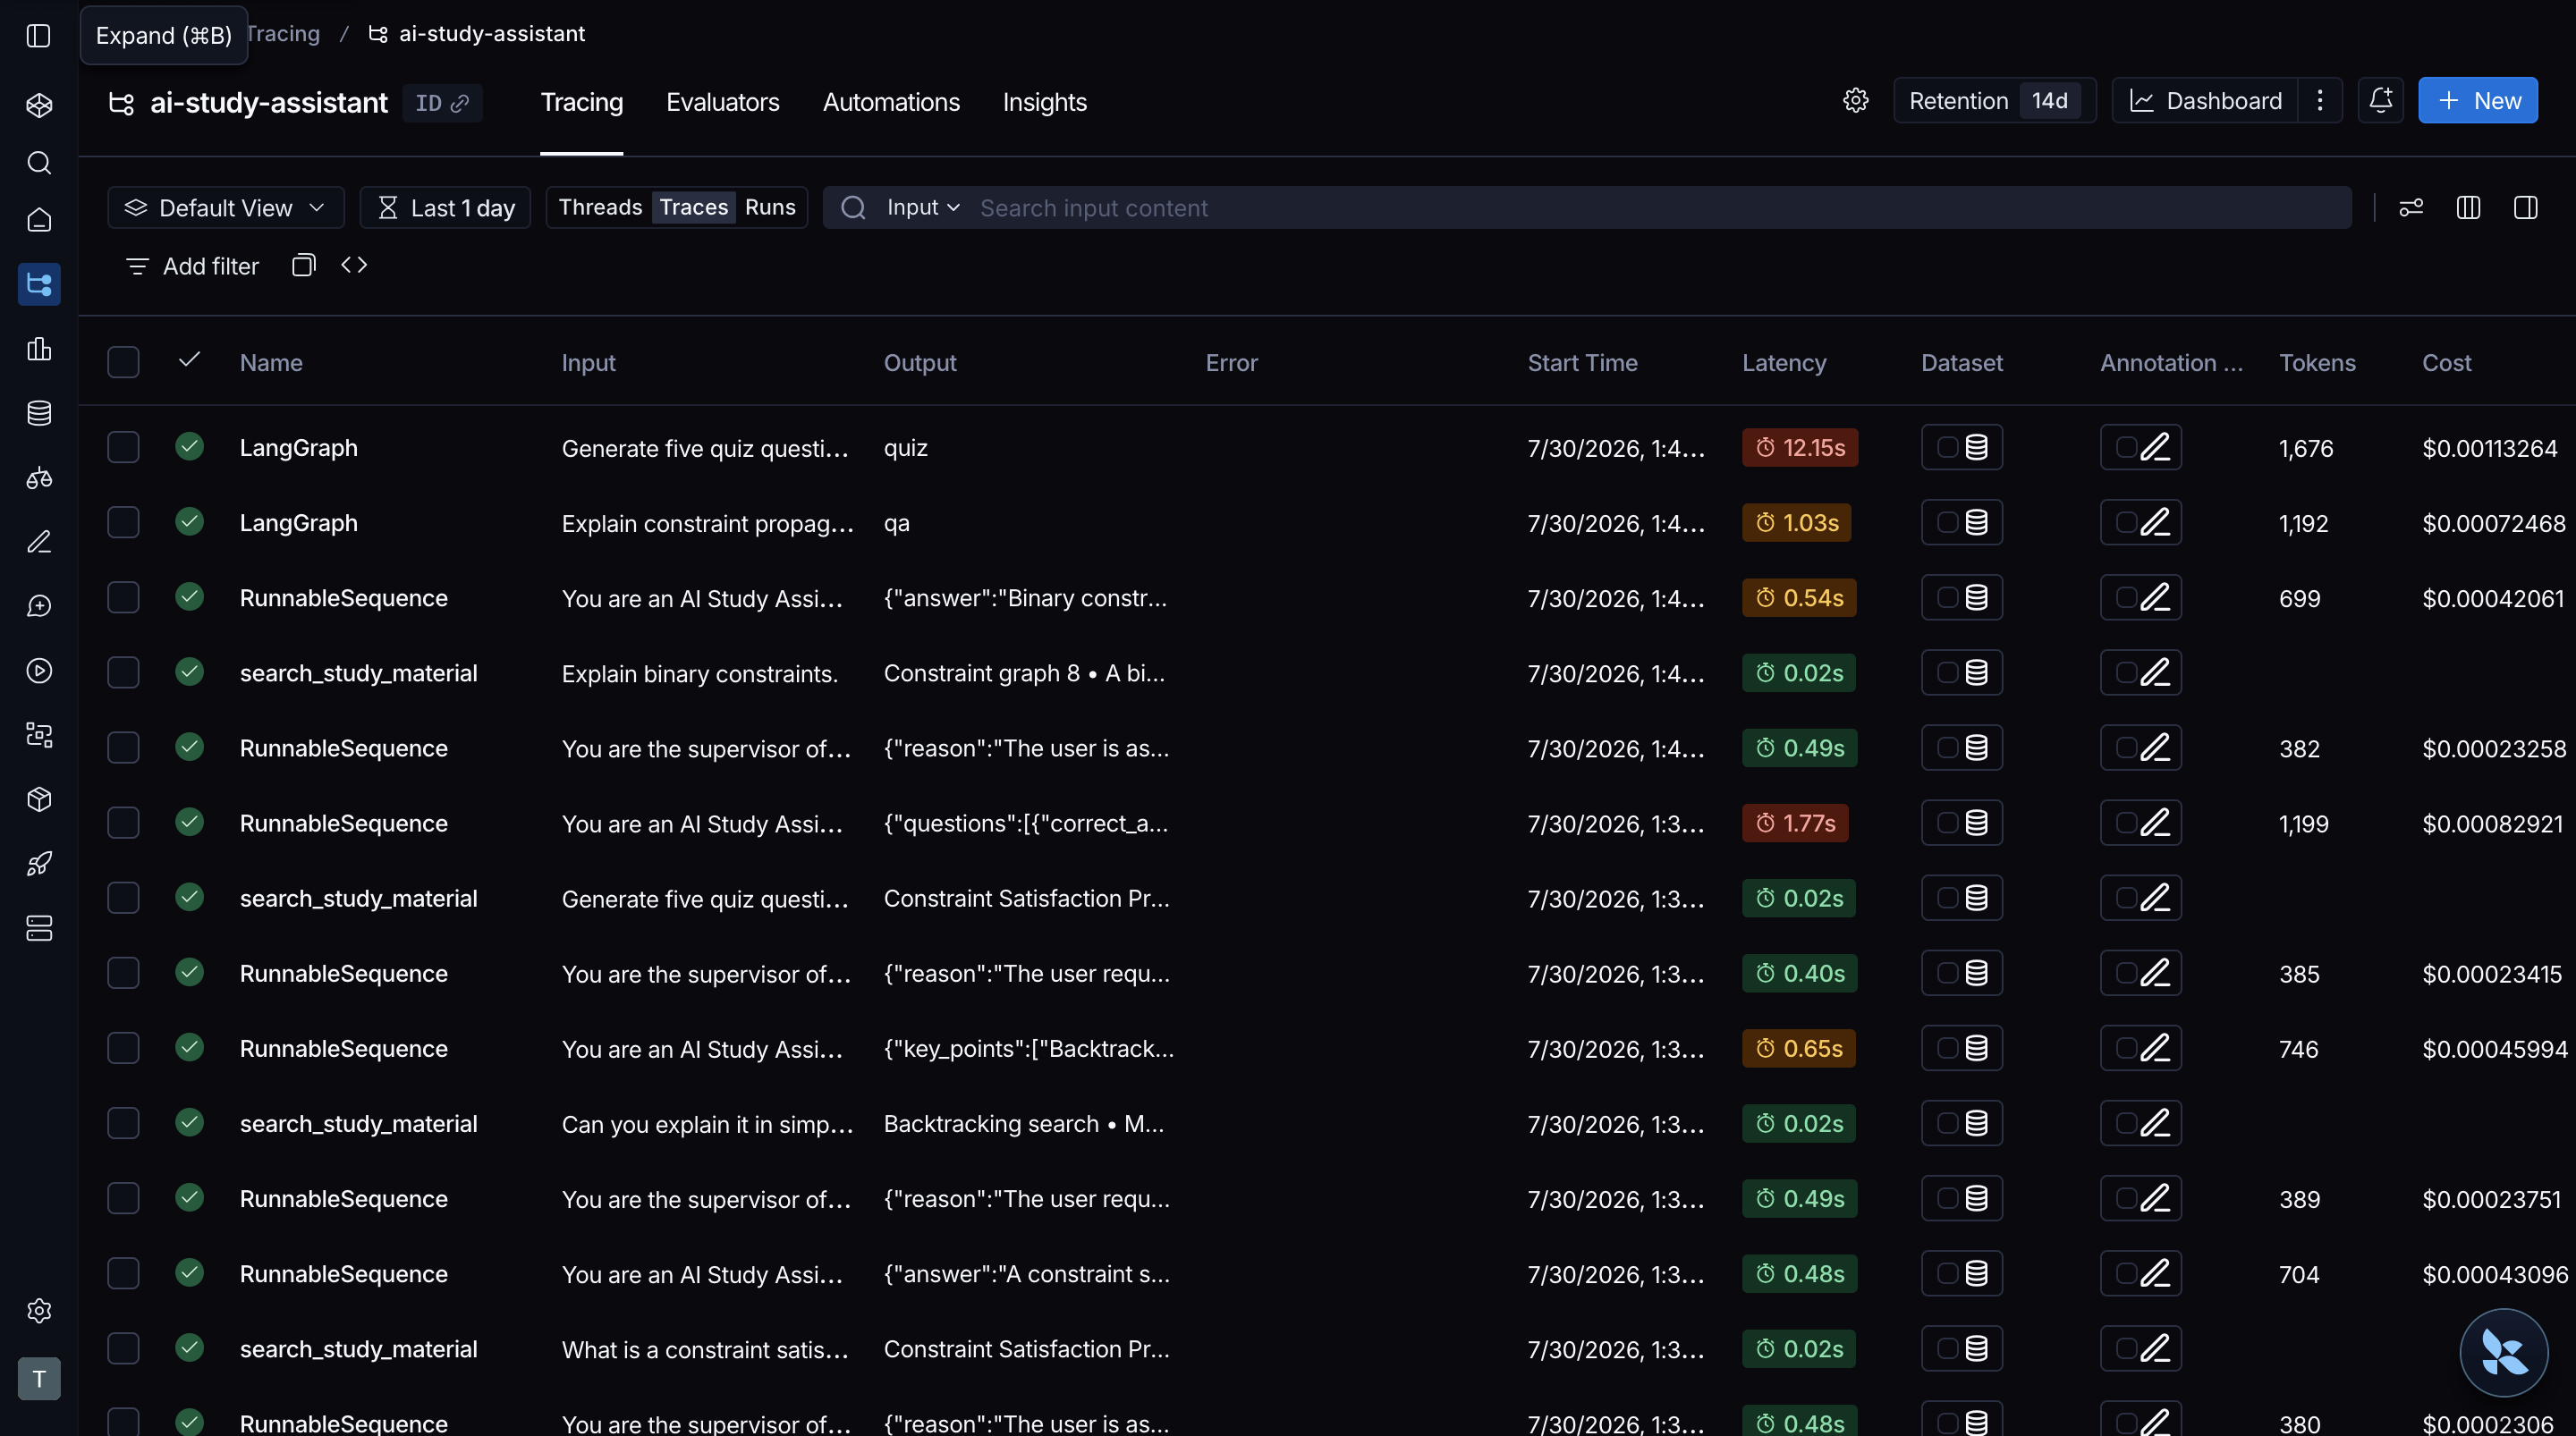

### LangSmith Monitoring Evidence

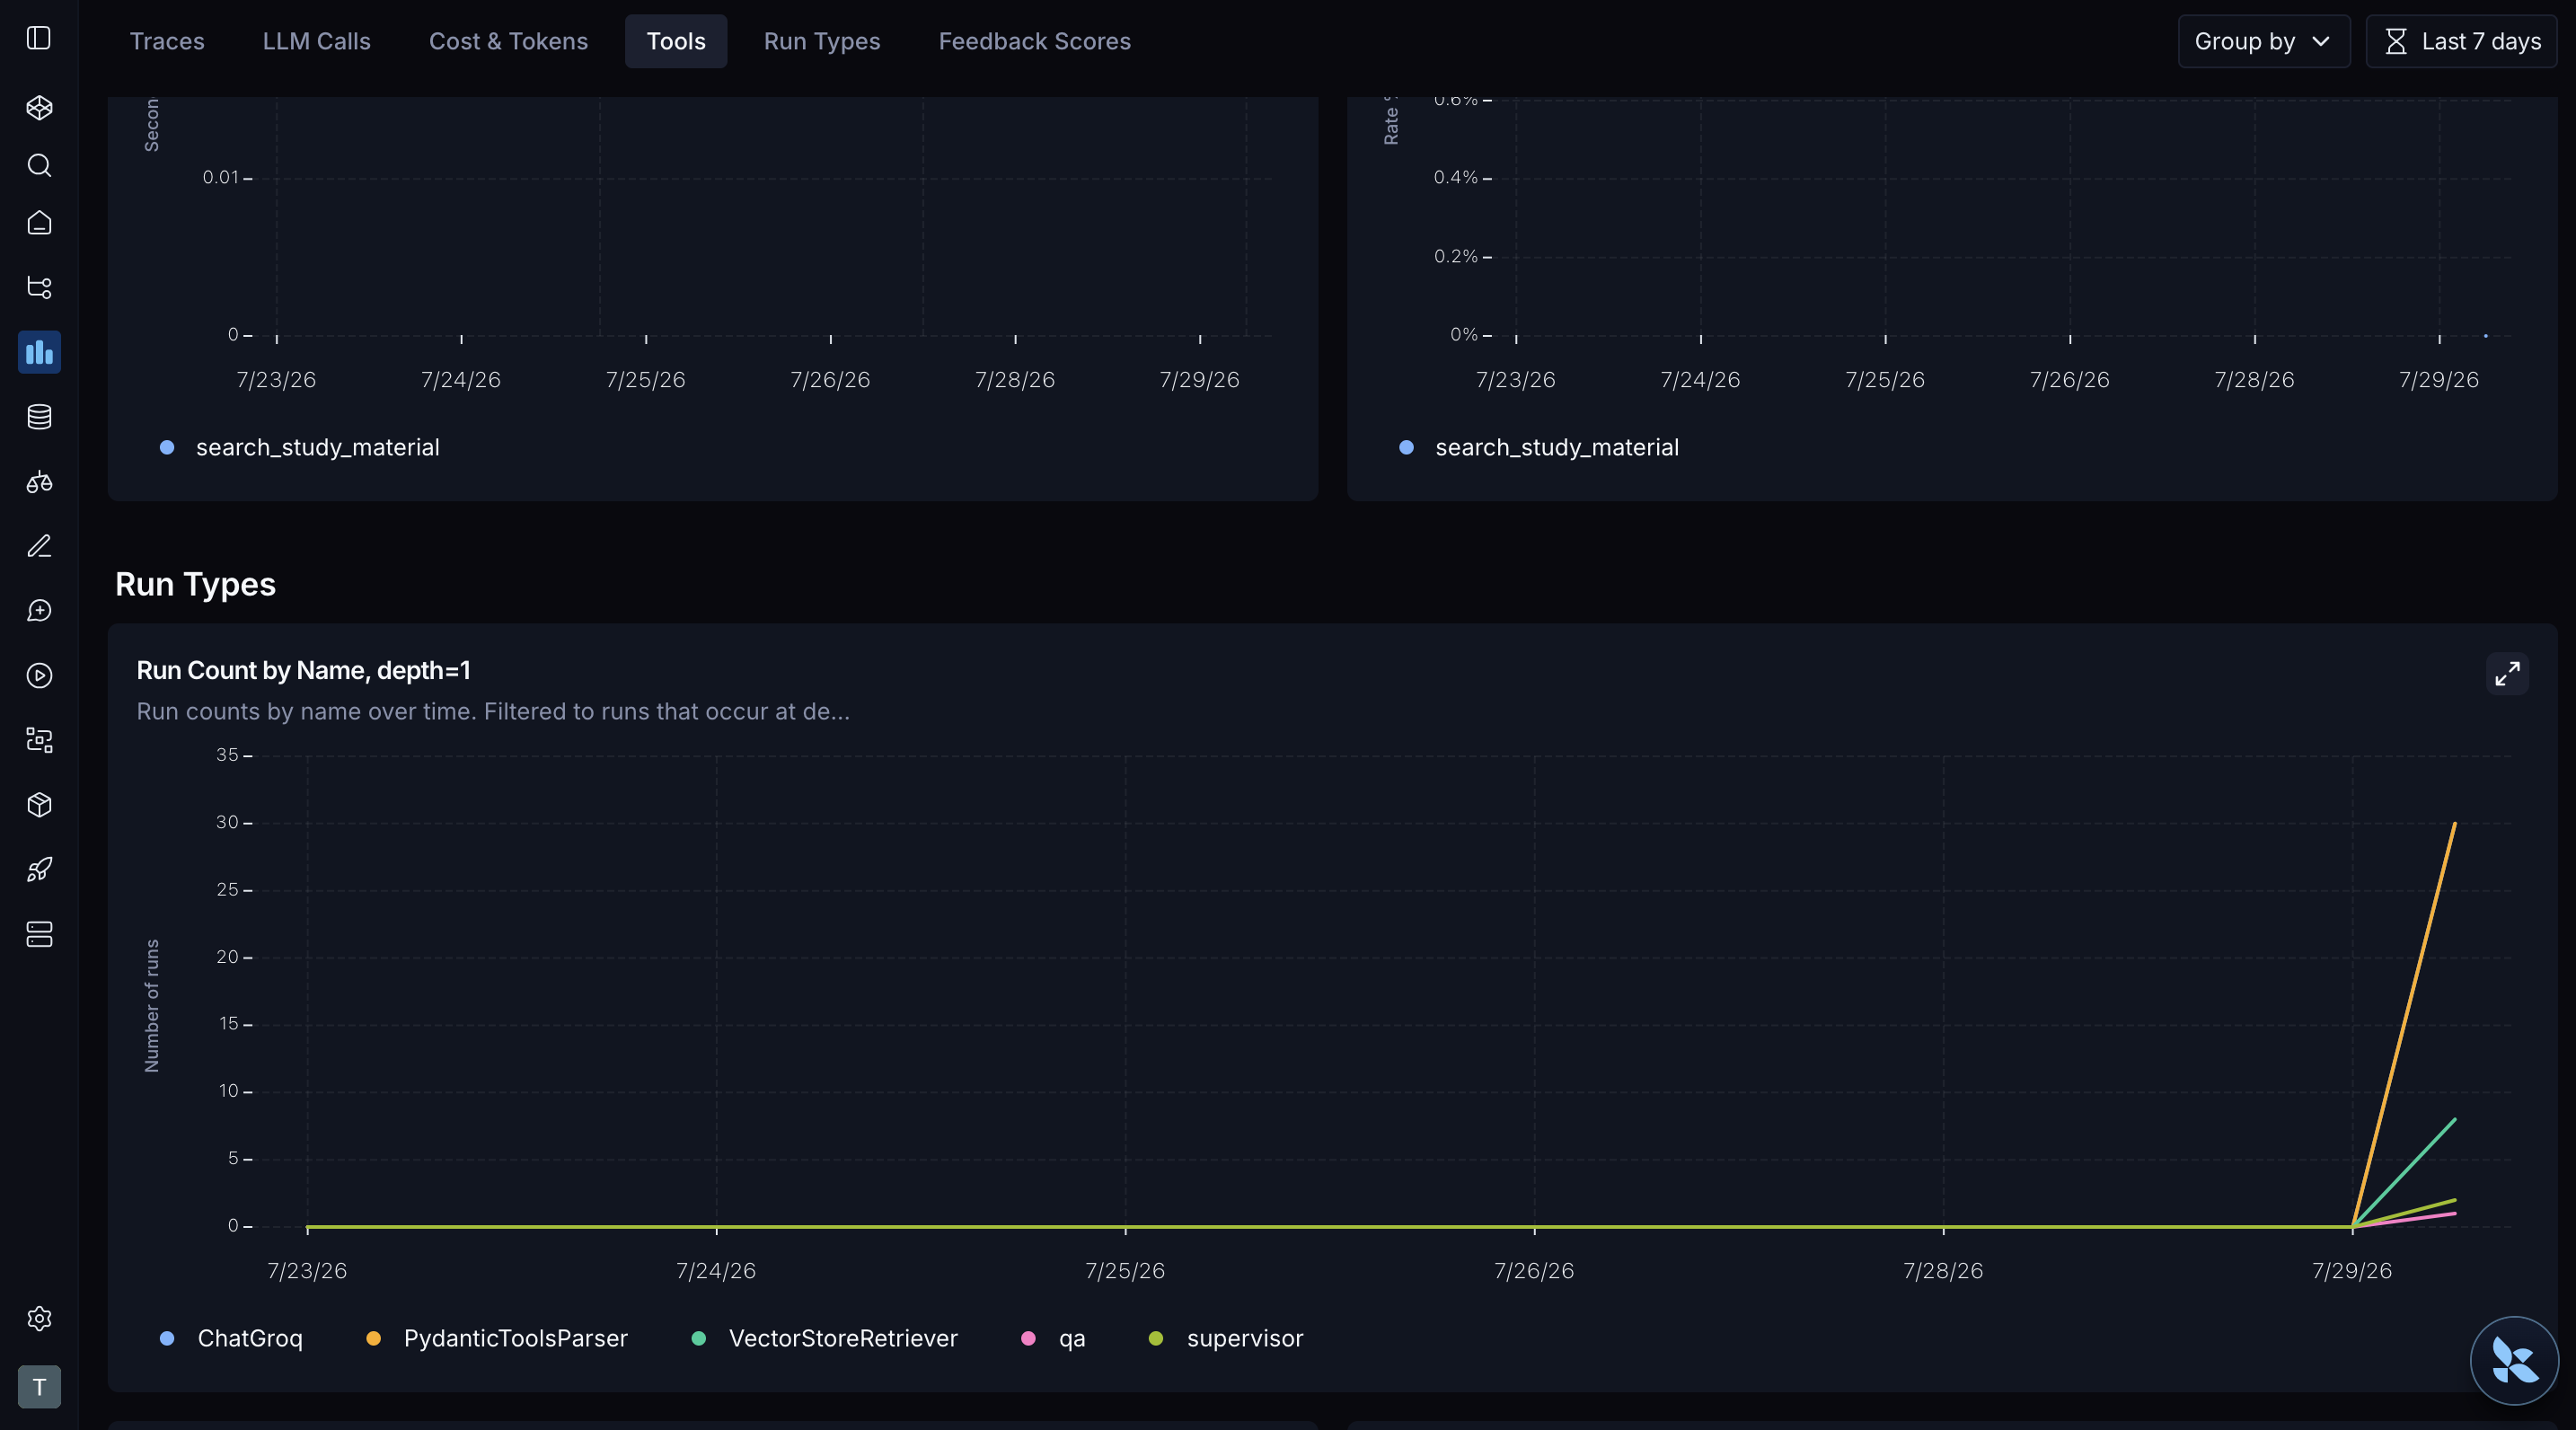

# Limitations and Future Improvements

- `InMemorySaver` and `InMemoryStore` are suitable for a capstone demonstration but should be replaced with durable database-backed implementations in production.
- Image-only or scanned PDFs require an OCR pipeline.
- Retrieval quality depends on document quality, chunking, and the embedding model.
- The selected Groq model and external model downloads require an internet connection.
- A production interface should validate uploads, enforce file-size limits, and provide authentication.

# Conclusion

The final AI Study Assistant is an end-to-end multi-agent application built with the LangGraph Functional API. It uses a true Orchestrator–Worker pattern, grounded RAG, structured worker outputs, memory, Human-in-the-Loop approval, and LangSmith observability.


